##1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

#2. Load Dataset

In [2]:
df = pd.read_csv("BankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
print(df.shape)
print(df.columns)

(10127, 23)
Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')


##3. Data Cleaning

In [4]:
#Missing value
print(df.isna().sum())

#Duplicated value
print(f"Duplicated: {df.duplicated().sum()}")

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [5]:
#Drop columns that are not useful for prediction
df.drop(columns=[
   "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
], inplace=True)

#Convert target variable to binary dara
df["Churn"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df.drop(columns="Attrition_Flag", inplace=True)

##EDA
*   The dataset is imbalanced, with significantly more existing customers than churned customers. This may cause models to become biased toward predicting non-churn cases.
*  Churned customers typically have lower transaction counts, suggesting that decreased card usage is associated with a higher likelihood of customer attrition.
*   Churned customers also show higher months of inactivity, indicating that declining customer engagement may contribute to churn.
*   Most customers have low credit utilization ratios, but churned customers display a slightly different distribution pattern, suggesting that utilization behavior may be associated with churn risk.
*   Correlation analysis shows weak relationships between churn and individual variables (correlation coefficients below 0.4), suggesting that churn is influenced by multiple combined factors rather than a single feature.














In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10127 non-null  int64  
 1   Gender                    10127 non-null  object 
 2   Dependent_count           10127 non-null  int64  
 3   Education_Level           10127 non-null  object 
 4   Marital_Status            10127 non-null  object 
 5   Income_Category           10127 non-null  object 
 6   Card_Category             10127 non-null  object 
 7   Months_on_book            10127 non-null  int64  
 8   Total_Relationship_Count  10127 non-null  int64  
 9   Months_Inactive_12_mon    10127 non-null  int64  
 10  Contacts_Count_12_mon     10127 non-null  int64  
 11  Credit_Limit              10127 non-null  float64
 12  Total_Revolving_Bal       10127 non-null  int64  
 13  Avg_Open_To_Buy           10127 non-null  float64
 14  Total_

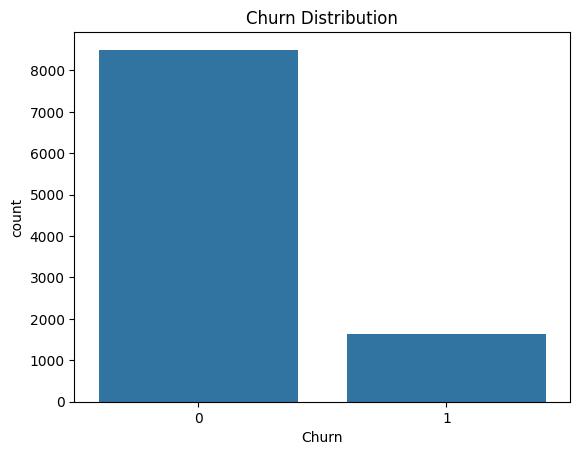

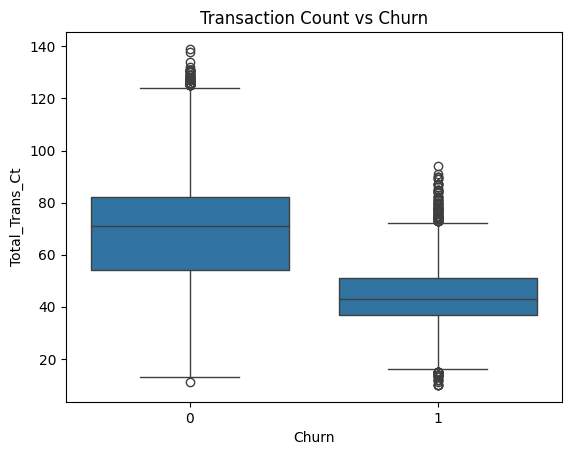

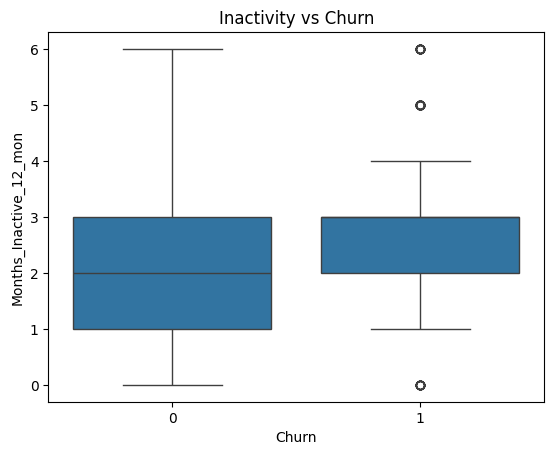

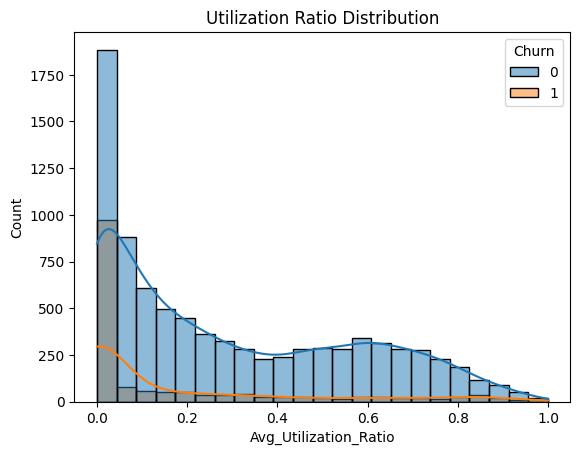

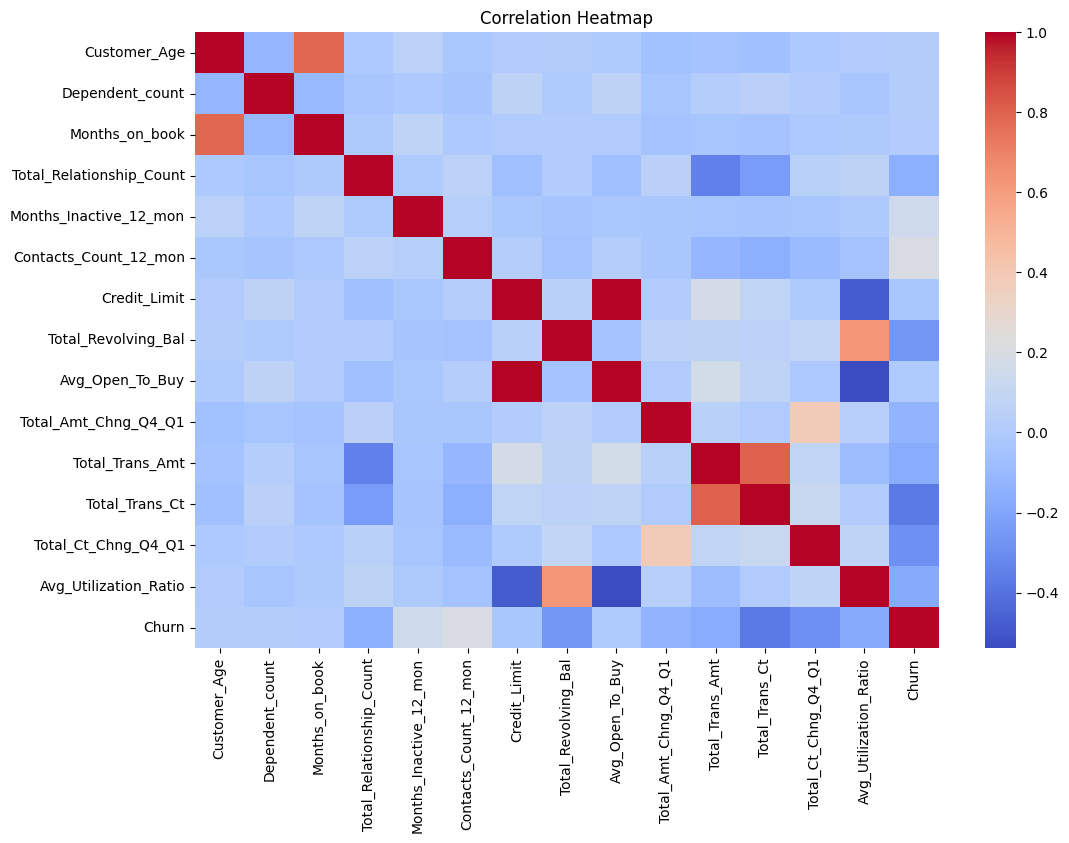

In [7]:
#Churn distribution
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")
plt.show()

#Transaction vs churn
sns.boxplot(data=df, x="Churn", y="Total_Trans_Ct")
plt.title("Transaction Count vs Churn")
plt.show()

#Inactivity vs churn
sns.boxplot(data=df, x="Churn", y="Months_Inactive_12_mon")
plt.title("Inactivity vs Churn")
plt.show()

#Utilization ratio
sns.histplot(data=df, x="Avg_Utilization_Ratio", hue="Churn", kde=True)
plt.title("Utilization Ratio Distribution")
plt.show()

#Correlation map
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##5. Feature / Target Split

In [8]:
#Split features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

##6. Train / Test Split

In [9]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


##7. Preprocessing

In [10]:
# OneHotEncode categorical variables

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

##8. Random Forest Model


*   The Random Forest model achieved 95% accuracy and a ROC-AUC score of 0.985, indicating strong predictive performance. While precision was high (93%), recall was lower (73%), suggesting there is still room for improvement in identifying churned customers.



In [11]:
#Random forest
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST RESULTS")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.93      0.73      0.82       325

    accuracy                           0.95      2026
   macro avg       0.94      0.86      0.89      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC: 0.9853868764979876


##9. XGBoost Model


*   The XGBoost model achieved 97% accuracy and a ROC-AUC score of 0.993, outperforming the Random Forest model. Its higher precision (97%) and recall (86%) indicate stronger performance in identifying customers likely to churn.



In [12]:
#XGBoost
xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_probs = xgb.predict_proba(X_test)[:,1]

print("XGBOOST RESULTS")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.97      0.86      0.91       325

    accuracy                           0.97      2026
   macro avg       0.97      0.93      0.95      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC: 0.9928639261972596


##10. Confusion Matrix

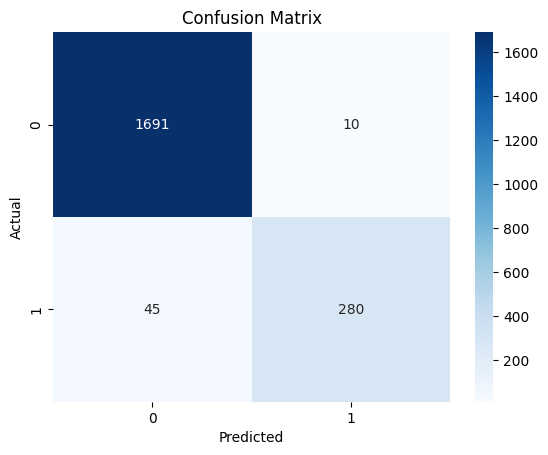

In [13]:
#Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##11. SHAP Explainability


*   SHAP analysis showed that features such as Total_Trans_Ct and Total_Trans_Amt had the greatest impact on churn prediction. Lower transaction counts and transaction amounts were associated with a higher likelihood of customer churn.



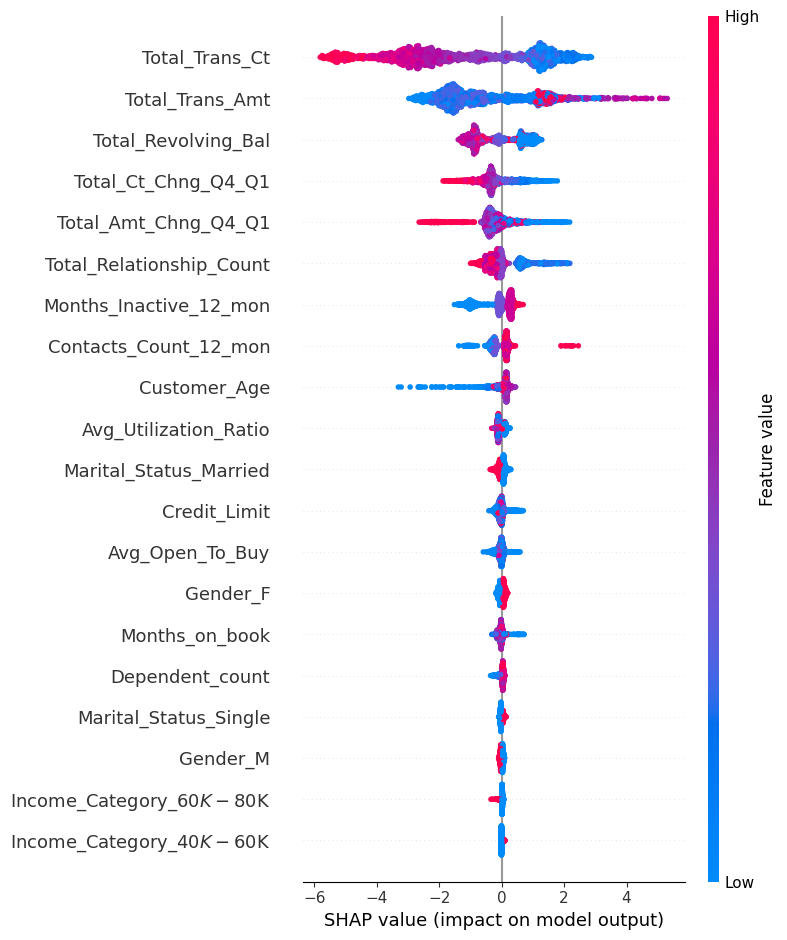

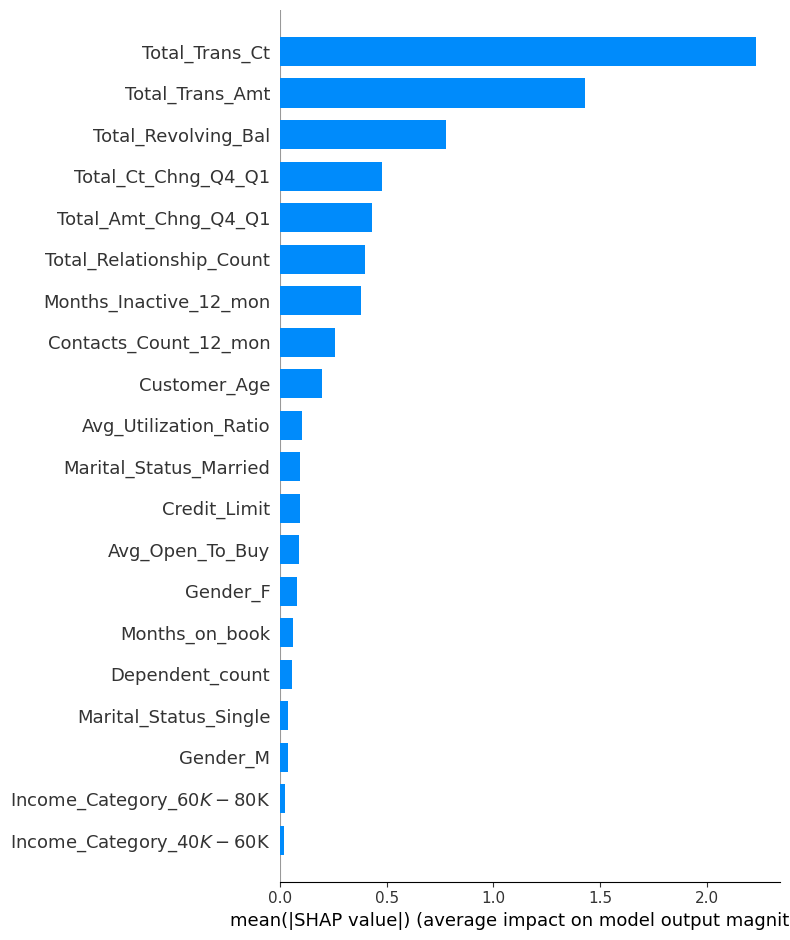

In [14]:
X_test_transformed = xgb.named_steps["preprocess"].transform(X_test)

cat_features = xgb.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_cols)

feature_names = np.concatenate([cat_features, numeric_cols])

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(xgb.named_steps["model"])
shap_values = explainer.shap_values(X_test_df)

#Summary plot
shap.summary_plot(shap_values, X_test_df)

#Feature importance plot
shap.summary_plot(shap_values, X_test_df, plot_type="bar")